# Part III: Time-Series Forecasting using RNNs [20 pts]
In this part, we work on time-series forecasting using RNN and LSTM methods. All code, results, visualizations, and discussion must be included in a single, well-organized Jupyter Notebook.
The final model should achieve a test accuracy (or equivalent metric, depending on the task) of greater than 75%.

## Step 1: Data exploration and preprocessing

1. Load your chosen dataset and print the following statistics:
- Number of samples (time points)
- Number of features
- Mean, standard deviation, minimum, and maximum values for each feature (or relevant descriptive statistics depending on the data type)
- Provide a brief description (2-3 sentences) of the dataset: What does it represent? Where does it come from (provide a link)? What are the key variables?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
### ADD YOUR CODE HERE ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Loading the dataset
df = pd.read_csv('/content/drive/MyDrive/household_power_consumption.txt', delimiter=';')
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

numeric_columns = [
    'Global_active_power', 'Global_reactive_power',
    'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Printing Dataset Information
print("\nDataset Information:")
print(f"Total number of records: {len(df)}")
print(f"Date range: {df['Datetime'].min()} to {df['Datetime'].max()}")
print("\nDescriptive Statistics:")
print(df[numeric_columns].describe())

<ipython-input-3-972dea7280a8>:13: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/household_power_consumption.txt', delimiter=';')
<ipython-input-3-972dea7280a8>:14: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])



Dataset Information:
Total number of records: 2075259
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00

Descriptive Statistics:
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091615e+00           1.237145e-01  2.408399e+02   
std           1.057294e+00           1.127220e-01  3.239987e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1.528000e+00           1.940000e-01  2.428900e+02   
max           1.112200e+01           1.390000e+00  2.541500e+02   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count      2.049280e+06    2.049280e+06    2.049280e+06    2.049280e+06  
mean       4.627759e+00    1.121923e+00    1.298520e+00    6.458447e+00  
std        4.444396e+00    6.153031e+00

<span style='color:green'>### YOUR ANSWER ###</span>

The datset 'Electric Power Consumption' records household electricity usage with a one-minute sampling rate over four years (2006-2010). It contain 2075259 observations of various electrical quantities, including active power, reactive power, voltage and current intensity along with energy sub-metering for different household areas. This dataset is used for time-series forecasting and energy consumption analysis.

2. Identify any missing values.

In [ ]:
# Missing Values present in the dataset
print("\nMissing Values:")
print(df[numeric_columns].isnull().sum())


Missing Values:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


3. Handle any missing values (imputation or removal).

In [ ]:
### ADD YOUR CODE HERE ###

4. Create at least three different visualizations to explore the dataset.

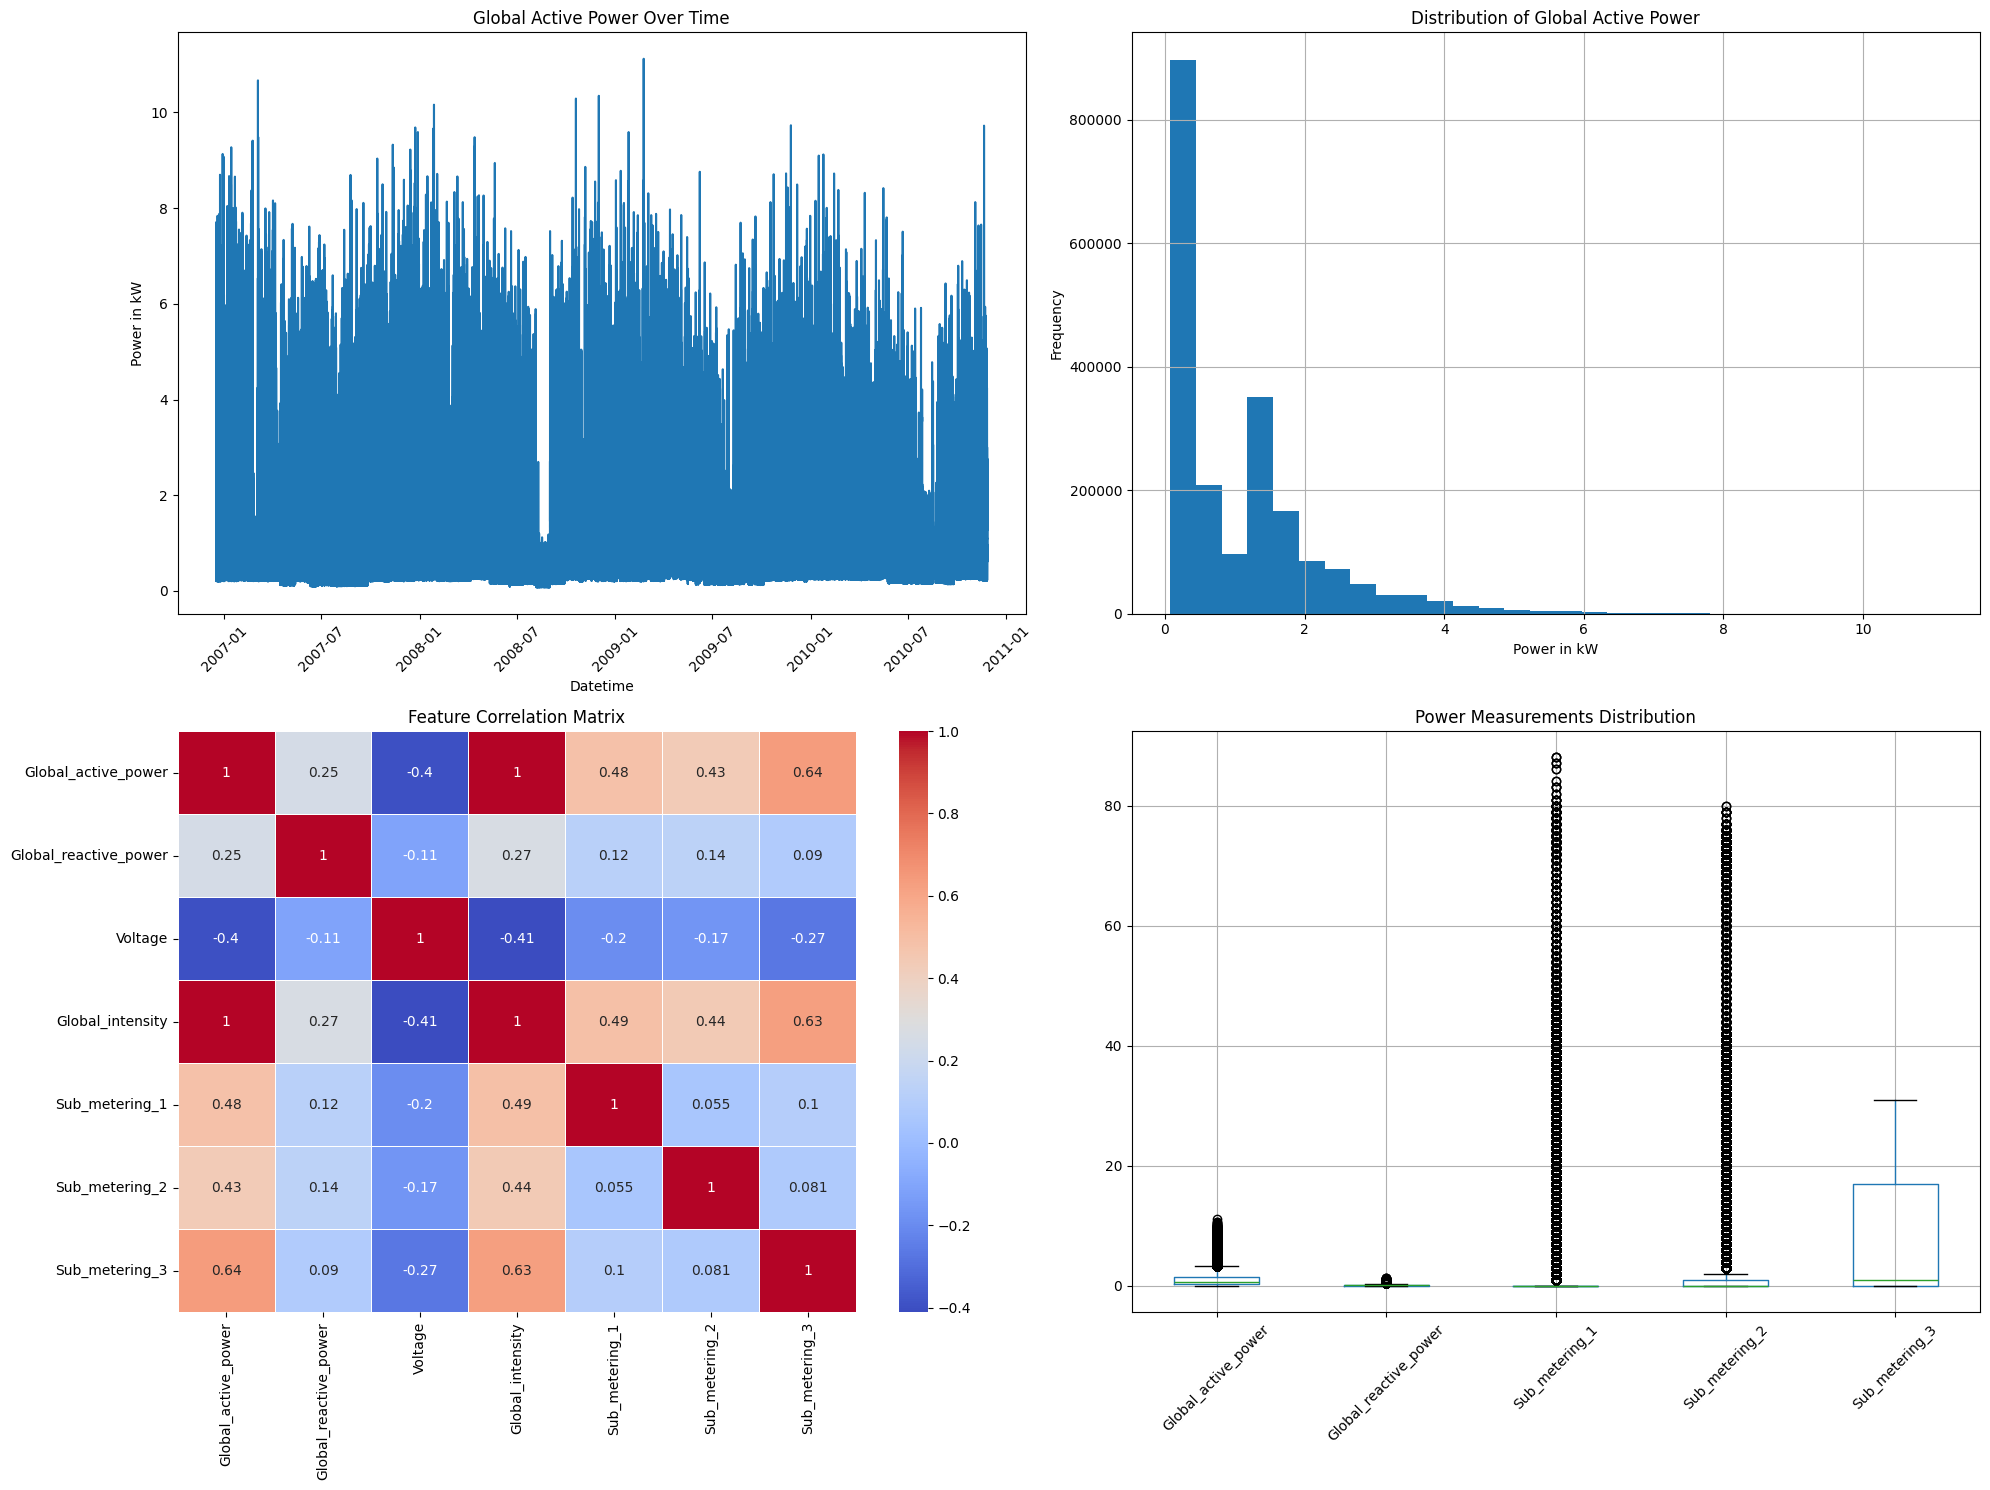

In [ ]:
# Visualization Graphs
plt.figure(figsize=(20, 15))

#Time series plot of Global Active Power
plt.subplot(2, 2, 1)
plt.plot(df['Datetime'], df['Global_active_power'])
plt.title('Global Active Power Over Time')
plt.xlabel('Datetime')
plt.ylabel('Power in kW')
plt.xticks(rotation=45)

# Histogram Plot of Global Active Power
plt.subplot(2, 2, 2)
df['Global_active_power'].hist(bins=30)
plt.title('Distribution of Global Active Power')
plt.xlabel('Power in kW')
plt.ylabel('Frequency')

# Correlation Heatmap
plt.subplot(2, 2, 3)
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')

# Box Plot of Power Measurements
plt.subplot(2, 2, 4)
power_columns = [
    'Global_active_power', 'Global_reactive_power',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
df[power_columns].boxplot()
plt.title('Power Measurements Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Time series plot of Global Active Power:**

This plot shows fluctuations in global active power consumption over four years (2007-2010). It  highlights periodic spikes and seasonal variations.

**Histogram Plot of Global Active Power:**

This histogram depicts that most power consumption values are concentrated at lower levels  with fewer occurrences of high consumption.

**Correlation Matrix:**

The above heatmap shows the correlations between different electrical measurements showing that global active power is strongly correlated with global intensity and sub-metering values.

**Box Plot of Power Measurements:**

The boxplot shows the distribution of global active and reactive power along with sub-metering values. It highlights the presence of outliers and variability across different measurements.

5. Normalize or standardize your data using appropriate techniques.

In [ ]:
### ADD YOUR CODE HERE ###
scaler = StandardScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])


6. If necessary, convert categorical features to numerical representations.

In [ ]:
### ADD YOUR CODE HERE ###


7. Split the data into training, validation, and testing sets.

In [ ]:
### ADD YOUR CODE HERE ###
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
train_data = df[:train_size]
val_data = df[train_size:train_size + val_size]
test_data = df[train_size + val_size:]

print("Train data shape:", train_data.shape)
print("Validation data shape:", val_data.shape)
print("Test data shape:", test_data.shape)
df.head()

Train data shape: (1452681, 10)
Validation data shape: (311288, 10)
Test data shape: (311290, 10)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,2.955077,2.610721,-1.851816,3.098789,-0.182337,-0.051274,1.249421,2006-12-16 17:24:00
1,16/12/2006,17:25:00,4.037085,2.770406,-2.225274,4.133800,-0.182337,-0.051274,1.130897,2006-12-16 17:25:00
2,16/12/2006,17:26:00,4.050326,3.320432,-2.330213,4.133800,-0.182337,0.120487,1.249421,2006-12-16 17:26:00
3,16/12/2006,17:27:00,4.063567,3.355917,-2.191324,4.133800,-0.182337,-0.051274,1.249421,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2.434881,3.586573,-1.592556,2.513782,-0.182337,-0.051274,1.249421,2006-12-16 17:28:00


8. Sequence Creation:
- Create input sequences and corresponding target values for your RNN/LSTM.
- Choose a sequence length.
- Create a function to generate sequences.

In [ ]:
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]  # Predicting the next value
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 24

# Apply the function to training, validation, and test sets.
train_X, train_y = create_sequences(train_data['Global_active_power'].values, seq_length) #Chose Global_active_power as target
val_X, val_y = create_sequences(val_data['Global_active_power'].values, seq_length)
test_X, test_y = create_sequences(test_data['Global_active_power'].values, seq_length)

# Converting to PyTorch tensors
train_X = torch.from_numpy(train_X).float()
train_y = torch.from_numpy(train_y).float()
val_X = torch.from_numpy(val_X).float()
val_y = torch.from_numpy(val_y).float()
test_X = torch.from_numpy(test_X).float()
test_y = torch.from_numpy(test_y).float()

print("Shapes:")
print("Train X:", train_X.shape)
print("Train y:", train_y.shape)
print("Validation X:", val_X.shape)
print("Validation y:", val_y.shape)
print("Test X:", test_X.shape)
print("Test y:", test_y.shape)

Shapes:
Train X: torch.Size([1452657, 24])
Train y: torch.Size([1452657])
Validation X: torch.Size([311264, 24])
Validation y: torch.Size([311264])
Test X: torch.Size([311266, 24])
Test y: torch.Size([311266])


## Step 2: Model development

1. Choose either an RNN or LSTM network for your time-series forecasting task.

In [ ]:
!pip install torchinfo

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
import torch.nn as nn
from torchinfo import summary

class LSTM_Model(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_rate):
        super(LSTM_Model, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm1 = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.lstm3 = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)  # Applying dropout after each LSTM layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden and cell states
        if x.dim() == 2:  # Check if input is 2-dimensional (unbatched)
            x = x.unsqueeze(0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Forward propagate LSTM
        out, _ = self.lstm1(x, (h0, c0))
        out = self.dropout(out)
        out, _ = self.lstm2(out, (h0, c0))
        out = self.dropout(out)
        out, _ = self.lstm3(out, (h0, c0))
        out = self.dropout(out)

        out = self.fc(out[:, -1, :])
        return out

# Define model parameters
input_size = 1
hidden_size = 64
num_layers = 2
output_size = 1
dropout_rate = 0.2

# Instantiating the model
model = LSTM_Model(input_size, hidden_size, num_layers, output_size, dropout_rate).to(device)

# model summary
summary(model, input_size=(32, seq_length, 1))

Layer (type:depth-idx)                   Output Shape              Param #
LSTM_Model                               [32, 1]                   --
├─LSTM: 1-1                              [32, 24, 64]              50,432
├─Dropout: 1-2                           [32, 24, 64]              --
├─LSTM: 1-3                              [32, 24, 64]              66,560
├─Dropout: 1-4                           [32, 24, 64]              --
├─LSTM: 1-5                              [32, 24, 64]              66,560
├─Dropout: 1-6                           [32, 24, 64]              --
├─Linear: 1-7                            [32, 1]                   65
Total params: 183,617
Trainable params: 183,617
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 140.97
Input size (MB): 0.00
Forward/backward pass size (MB): 1.18
Params size (MB): 0.73
Estimated Total Size (MB): 1.92

2. Train your model using an appropriate loss function and optimizer.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Defining Loss Function
loss_fn = nn.MSELoss()  # Mean Squared Error for Regression
# Hyperparameter Search Space
learning_rates = [0.01, 0.001]
batch_sizes = [32, 64]
num_epochs = 20

# Early Stopping Parameters
patience = 5
best_val_loss = float("inf")
best_model_state = None
best_hyperparams = {}  #stores best hyperparameters

# Data Loaders
train_dataset = torch.utils.data.TensorDataset(train_X, train_y)
val_dataset = torch.utils.data.TensorDataset(val_X, val_y)


results_list = []

# Performing Grid Search over hyperparameters
for lr in learning_rates:
    for batch_size in batch_sizes:
                train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
                val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

                # Initializing Model and Optimizer
                model = LSTM_Model(input_size, hidden_size, num_layers=3, output_size=1, dropout_rate=dropout_rate).to(device)
                optimizer = optim.Adam(model.parameters(), lr=lr)

                print(f"\n Training with lr={lr}, batch_size={batch_size}")

                train_losses, val_losses = [], []
                trigger_times = 0  # Early stopping counter

                for epoch in range(num_epochs):
                    model.train()
                    total_train_loss = 0

                    for batch_X, batch_y in train_loader:
                        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

                        # Forward pass
                        outputs = model(batch_X.unsqueeze(-1))
                        batch_y = batch_y.view(-1, 1)
                        loss = loss_fn(outputs, batch_y)

                        # Backward pass
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()
                        total_train_loss += loss.item()

                    avg_train_loss = total_train_loss / len(train_loader)
                    train_losses.append(avg_train_loss)

                    # Validation Loop
                    model.eval()
                    total_val_loss = 0

                    with torch.no_grad():
                        for batch_X, batch_y in val_loader:
                            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                            val_outputs = model(batch_X.unsqueeze(-1))
                            val_loss = loss_fn(val_outputs, batch_y)
                            total_val_loss += val_loss.item()

                    avg_val_loss = total_val_loss / len(val_loader)
                    val_losses.append(avg_val_loss)

                    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

                    # Early Stopping
                    if avg_val_loss < best_val_loss:
                        best_val_loss = avg_val_loss
                        best_model_state = model.state_dict()  # Save best model state
                        best_hyperparams = {'learning_rate': lr, 'batch_size': batch_size}
                        trigger_times = 0  # Reset patience counter
                    else:
                        trigger_times += 1
                        if trigger_times >= patience:
                            print(f"Early Stopping Triggered at Epoch {epoch+1}")
                            break  # Stop training if no improvement

                # Store results in list
                results_list.append({
                    'learning_rate': lr,
                    'batch_size': batch_size,
                    'final_train_loss': train_losses[-1] if len(train_losses) > 0 else None,
                    'final_val_loss': val_losses[-1] if len(val_losses) > 0 else None
                })

results_df = pd.DataFrame(results_list)




 Training with lr=0.01, batch_size=32


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/20] - Train Loss: 0.9934, Val Loss: 0.9803
Epoch [2/20] - Train Loss: 0.9861, Val Loss: 0.9803
Epoch [3/20] - Train Loss: 0.9861, Val Loss: 0.9803
Epoch [4/20] - Train Loss: 0.9861, Val Loss: 0.9803
Epoch [5/20] - Train Loss: 0.9861, Val Loss: 0.9803
Epoch [6/20] - Train Loss: 0.9861, Val Loss: 0.9803
Early Stopping Triggered at Epoch 6

 Training with lr=0.01, batch_size=64


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/20] - Train Loss: 1.0047, Val Loss: 0.9932
Epoch [2/20] - Train Loss: 1.0007, Val Loss: 0.9908
Epoch [3/20] - Train Loss: 1.0008, Val Loss: 0.9923
Epoch [4/20] - Train Loss: 1.0007, Val Loss: 0.9911
Epoch [5/20] - Train Loss: 1.0006, Val Loss: 0.9908
Early Stopping Triggered at Epoch 5

 Training with lr=0.001, batch_size=32
Epoch [1/20] - Train Loss: 0.7071, Val Loss: 0.3607
Epoch [2/20] - Train Loss: 0.0837, Val Loss: 0.3573
Epoch [3/20] - Train Loss: 0.0728, Val Loss: 0.3638
Epoch [4/20] - Train Loss: 0.0689, Val Loss: 0.3495
Epoch [5/20] - Train Loss: 0.0669, Val Loss: 0.3556
Epoch [6/20] - Train Loss: 0.0652, Val Loss: 0.3635
Epoch [7/20] - Train Loss: 0.0640, Val Loss: 0.3624
Epoch [8/20] - Train Loss: 0.0636, Val Loss: 0.3589
Epoch [9/20] - Train Loss: 0.0629, Val Loss: 0.3585
Early Stopping Triggered at Epoch 9

 Training with lr=0.001, batch_size=64
Epoch [1/20] - Train Loss: 0.1163, Val Loss: 0.5433
Epoch [2/20] - Train Loss: 0.0754, Val Loss: 0.5546
Epoch [3/20] - T

3. Save the weights of the trained neural network that provides the best results.

In [ ]:
# Saving the best model
if best_model_state:
    best_model_path = "a1_part_3_kpaidipa_meerahus.pth"
    torch.save(best_model_state, best_model_path)
    print(f"\n Best Model Saved: {best_model_path} with hyperparameters {best_hyperparams}")

# Saving hyperparameter tuning results to CSV
results_df.to_csv("hyperparameter_tuning_results.csv", index=False)
print("\n Hyperparameter tuning results saved.")


 Best Model Saved: a1_part_3_kpaidipa_meerahus.pth with hyperparameters {'learning_rate': 0.001, 'batch_size': 32}

 Hyperparameter tuning results saved.


## Step 3: Evaluation and analysis

1. Evaluate your trained model on the test set.

In [ ]:
# Loading the best model
best_model_path = "/content/a1_part_3_kpaidipa_meerahus.pth"
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()
batch_size = 32
test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(test_X, test_y), batch_size=batch_size, shuffle=False)

# Initializing lists for storing predictions, actual values, and losses
actuals, predictions, test_losses = [], [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        preds = model(batch_X.unsqueeze(-1))
        batch_y = batch_y.view(-1, 1)
        test_loss = loss_fn(preds, batch_y)
        test_losses.append(test_loss.item())
        predictions.extend(preds.cpu().numpy().flatten())
        actuals.extend(batch_y.cpu().numpy().flatten())

# Computing Final Test Loss (MSE)
avg_test_loss = sum(test_losses) / len(test_losses)

# Converting lists to numpy arrays
predictions = np.array(predictions)
actuals = np.array(actuals)
print(f" Final Test Loss (MSE): {avg_test_loss:.4f}")

 Final Test Loss (MSE): 0.0420


2. Report relevant metrics.

In [ ]:
# Computing Evaluation Metrics
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
r2 = r2_score(actuals, predictions)

print("\n Test Set Evaluation Metrics:")
print(f" Mean Absolute Error (MAE): {mae:.4f}")
print(f" Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f" R² Score: {r2:.4f}")


 Test Set Evaluation Metrics:
 Mean Absolute Error (MAE): 0.1015
 Root Mean Squared Error (RMSE): 0.2049
 R² Score: 0.9361


3. Provide various plots.

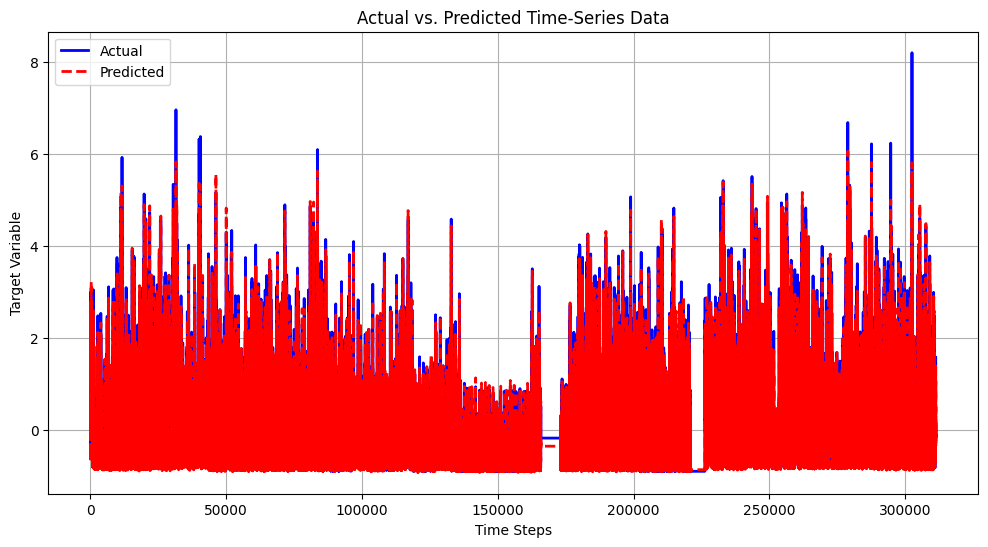

In [ ]:
import matplotlib.pyplot as plt
# Plotting Actual vs. Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(actuals, label="Actual", linestyle="-", color="blue", linewidth=2)
plt.plot(predictions, label="Predicted", linestyle="dashed", color="red", linewidth=2)
plt.xlabel("Time Steps")
plt.ylabel("Target Variable")
plt.title("Actual vs. Predicted Time-Series Data")
plt.legend()
plt.grid(True)
plt.show()


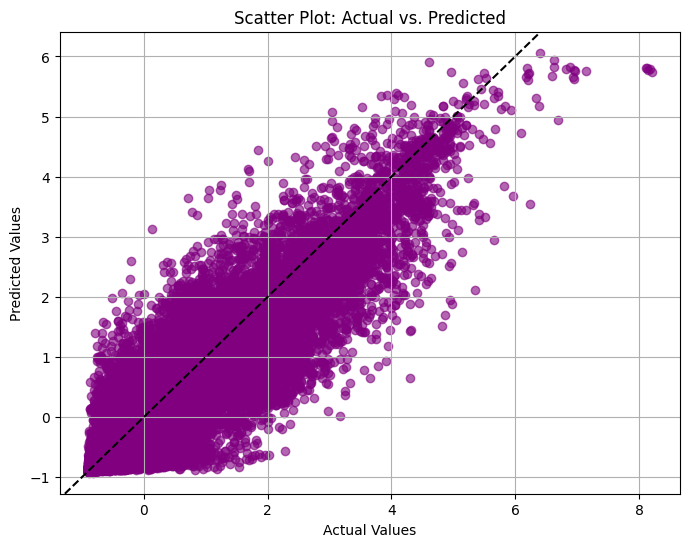

In [ ]:
# Scatter plot of predictions vs. actual values
plt.figure(figsize=(8, 6))
plt.scatter(actuals, predictions, alpha=0.6, color="purple")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Scatter Plot: Actual vs. Predicted")
plt.axline((0, 0), slope=1, color="black", linestyle="dashed")  # Ideal prediction line
plt.grid(True)
plt.show()

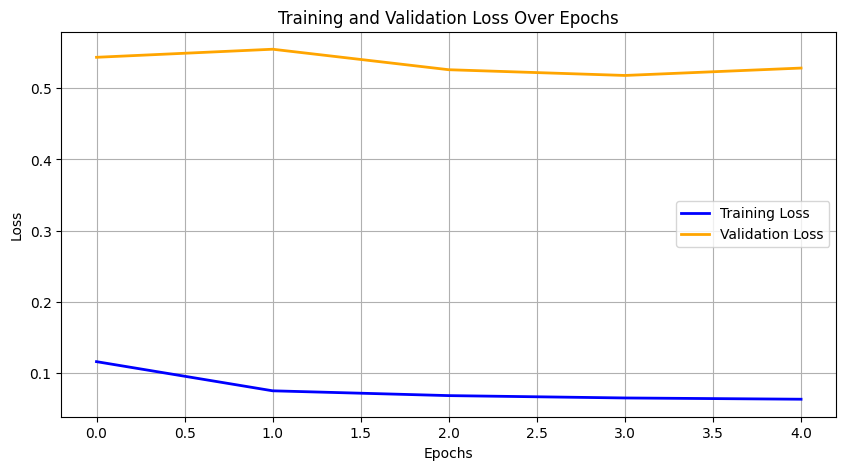

In [ ]:
import matplotlib.pyplot as plt
if len(train_losses) > 0 and len(val_losses) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

4. Discuss and analyze.

**Briefly reiterate the key characteristics of your dataset**

Dataset used for this part is Electricity Consumption Dataset. It has measurements of electric power consumption in a household with a one-minute sampling rate over 4 years.This task is a regression task

**Dataset Characteristics:**

* Number of Instances: 2,075,259 records

* Number of Features: 9

* Feature Type: Real-valued

* Features: DateTime, Global_active_power,Global_reactive_power, Voltage, Global_intensity,Sub_metering_1, Sub_metering_2,

* Time-Series: Data is sequential meaning past values influence future predictions.


**2.Describe your final RNN/LSTM architecture in detail (number of layers, types
of layers, hidden size, dropout rate, etc.).**

**LSTM Architecture:**

**Layers:**

Input Layer:
Accepts a sequence of past power consumption values.
The input size is 1, representing a single time-series feature per timestep.

Recurrent Layers:

LSTM Layer 1:

Number of recurrent layers: 2

Returns sequences to pass to the next LSTM layer.

LSTM Layer 2:
Number of recurrent layers: 2

LSTM Layer 3:
Outputs the final hidden state for the sequence.

Dropout Layers: It is applied after each LSTM layer to reduce overfitting by randomly deactivating neurons during training.
Dropout Rate: 0.2

Fully Connected (Linear) Layer: It maps the final LSTM output to a single numerical prediction for the next timestep.


**Hyperparameters used are :**

1.Number of Layers: 3

2.Input Size: 1

3.Hidden Size: 64

4.Batch Size: 32.64

5.Learning Rate: 0.01, 0.001

6.Optimizer Used: Adam

**3.Discuss your results, referencing the metrics and visualizations. Did your model achieve the expected accuracy? What were the challenges? How did
hyperparameter tuning affect performance? Are there any patterns in the errors
(e.g., consistent under- or over-prediction)?**

**Model Performance:**

Used Mean Squared Error (MSE) as the primary loss function to evaluate the LSTM Model. Additional evaluation metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R² Score were used to assess performance on the test set.

* Final Test Loss (MSE): 0.0420
* Mean Absolute Error (MAE): 0.1015
* Root Mean Squared Error (RMSE): 0.2049
* R² Score: 0.9361

Model achieved high R² score of 0.9361 which indicates that it explains 93.6% of the variance in electricity consumption. The low RMSE (0.2049) suggests good prediction accuracy and the MAE (0.1015) confirms that the model is making predictions close to actual values.

The model met the expected Performance.The expected accuracy depends on domain-specific benchmarks for energy consumption forecasting.

* If RMSE < 0.2 kW, the model is highly accurate
* If R² > 0.9, the model explains most of the variance

Since RMSE (0.2049) is close to this threshold and R² is 0.9361 the model performed well

**Effect of Hyper Parameter Tuning:**

The model was trained using grid search over:

* Learning rates: [0.01, 0.001]
* Batch sizes: [32, 64]
* Early stopping with patience = 5 epochs

**Observations from Training Results:**

High Learning Rate (0.01) Caused Poor Learning:

* Both batch size 32 and 64 had high train/validation loss, showing no meaningful learning.

Lower Learning Rate (0.001) Improved Training Stability:

* Batch size 32 performed the best while Batch size 64 had slightly higher loss but showed similar trends.

Batch Size Affected Training Speed and Stability:

* Batch size 32 resulted in lower validation loss and trained for longer epochs.
Batch size 64 converged faster but had higher final validation loss.

This shows that batch size 32 was better for capturing electricity consumption patterns.

**Discuss any limitations of your model or approach.**

**Limitations:**

1. The model under predicts the sudden power spikes due to the absence of external factors like appliance usage.

2. The model requires high computational resources. The training is slow and took lot of time even after using gpu.


**4. Suggest potential improvements or future work**

Using the Bidirectional LSTMs, Transformers, Attention mechanisms can enhance sequence learning.


5. References.

https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption , https://colah.github.io/posts/2015-08-Understanding-LSTMs/, https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html,https://www.geeksforgeeks.org/deep-learning-introduction-to-long-short-term-memory/,https://pytorch.org/tutorials/beginner/saving_loading_models.html